# Hierarchical Clustering: Customer Spend Segmentation

## Problem Statement
Segment customers into meaningful groups based on spending patterns, to support targeted marketing.

## Dataset
**Customer Spend Data** -- per-customer spend across product categories.

## Approach
Z-score standardization, `AgglomerativeClustering` (average linkage, Euclidean distance) to assign 3 clusters, plus a dendrogram and cophenetic-correlation check to validate cluster quality.

## Conclusion
Produces 3 distinct customer segments with different average spend profiles -- a starting point for targeted campaigns per segment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
data=pd.read_csv('cust_Spend_Data.csv')

In [3]:
data.shape

(10, 7)

In [4]:
data.head()

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cust_ID          10 non-null     int64 
 1   Name             10 non-null     object
 2   Avg_Mthly_Spend  10 non-null     int64 
 3   No_Of_Visits     10 non-null     int64 
 4   Apparel_Items    10 non-null     int64 
 5   FnV_Items        10 non-null     int64 
 6   Staples_Items    10 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 688.0+ bytes


In [8]:
data_attr=data.iloc[:,2:]

In [9]:
data_attr

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,10000,2,1,1,0
1,7000,3,0,10,9
2,7000,7,1,3,4
3,6500,5,1,1,4
4,6000,6,0,12,3
5,4000,3,0,1,8
6,2500,5,0,11,2
7,2500,3,0,1,1
8,2000,2,0,2,2
9,1000,4,0,1,7


In [10]:
data_attr_scaled=data_attr.apply(zscore)

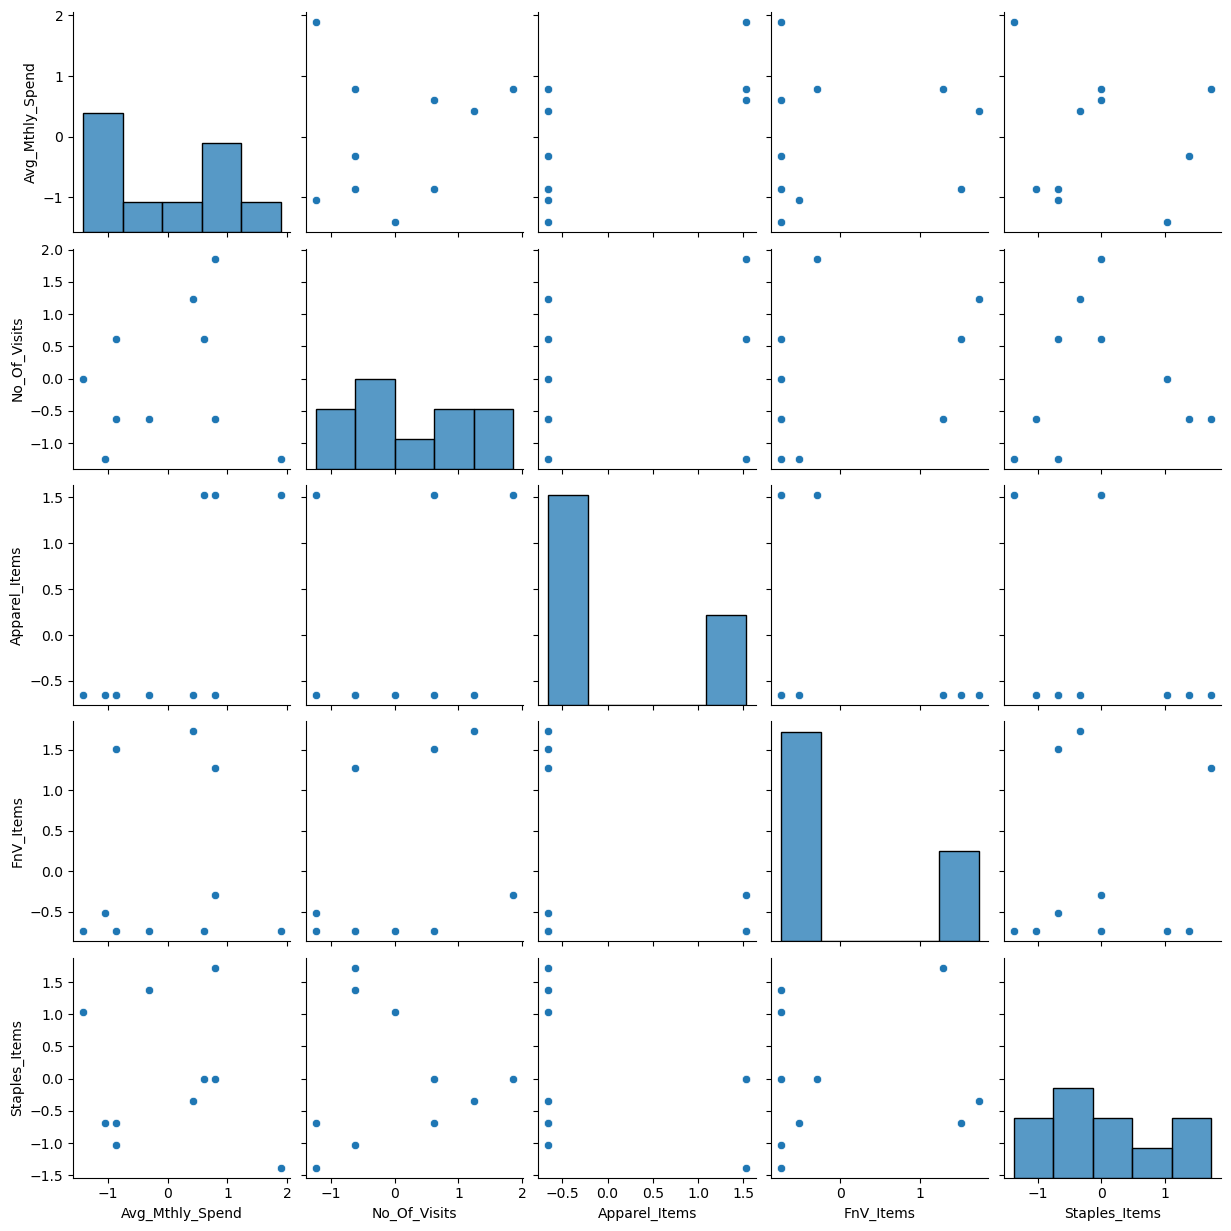

In [13]:
sns.pairplot(data_attr_scaled)

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [15]:
# 'affinity' renamed to 'metric' in sklearn 1.4+
model=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='average')

In [16]:
model.fit(data_attr_scaled)

C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


AgglomerativeClustering(affinity='euclidean', linkage='average', n_clusters=3)

In [19]:
data_attr['labels']=model.labels_

In [20]:
data_clustered=data_attr.groupby(['labels'])

In [21]:
data_clustered.mean()

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
labels,,,,,
0,7833.333333,4.666667,1.0,1.666667,2.666667
1,5166.666667,4.666667,0.0,11.000000,4.666667
2,2375.000000,3.000000,0.0,1.250000,4.500000


In [22]:
from scipy.cluster.hierarchy import cophenet,dendrogram,linkage

In [25]:
from scipy.spatial.distance import pdist

In [26]:
z=linkage(data_attr_scaled,metric='euclidean',method='average')

In [27]:
#cophenut index---- is measure of correlation between the distance of points
c,cop_dist=cophenet(z,pdist(data_attr_scaled))

<function matplotlib.pyplot.show(close=None, block=None)>

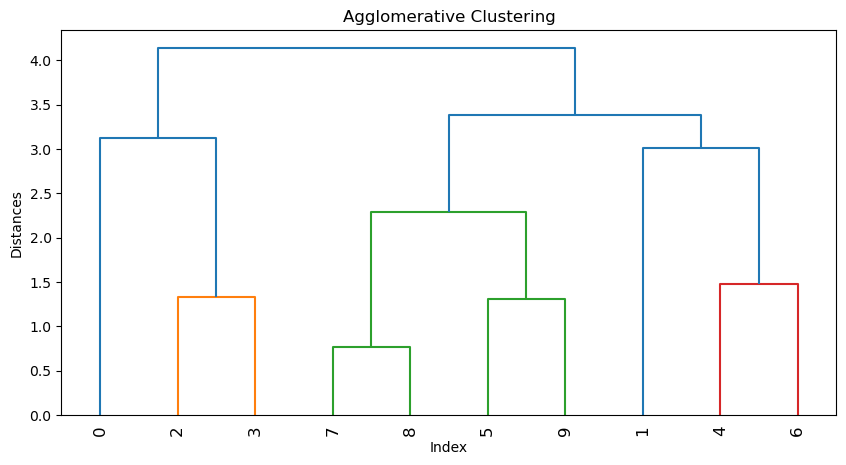

In [28]:
plt.figure(figsize=(10,5))
plt.title('Agglomerative Clustering')
plt.xlabel('Index')
plt.ylabel('Distances')
dendrogram(z,leaf_rotation=90.)
plt.show